# Fine-Tune Pretrained Commutative CNN Classifier

Load the pretrained commutative CNN encoder and fine-tune the full network on the current labeled action dataset.

In [7]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    CommutativeCNNClassifier,
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_chunked_water_vs_other_hot_start,
    fit_estimator_on_experiment,
    load_commutative_cnn_pretraining_config,
    persist_experiment_artifacts,
    plot_training_history,
    prepare_multitask_experiment_data,
    prepare_water_vs_other_pretraining_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import (
    build_tensor_embedding_2d,
    load_labeled_tensor_dataset,
    plot_tensor_embedding_2d,
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
unlabeled_dataset_path = Path(".dataset_cache/unlabeled_active_high_mid_low_t20_z5_y96_x96_chunks")
pretraining_config_path = Path("artifacts/pretrained_commutative_cnn/config.yaml")
pretraining_config = load_commutative_cnn_pretraining_config(pretraining_config_path)
print(f"Loaded commutative CNN pretraining config from {pretraining_config_path}")
print(pretraining_config)

pretrained_encoder_path = pretraining_config.pretrained_encoder_path
if not pretrained_encoder_path.exists():
    raise FileNotFoundError(
        f"Pretrained CNN encoder not found at {pretrained_encoder_path}. "
        "Run 10C_pretrain_commutative_cnn_encoder.ipynb first, or update "
        "artifacts/pretrained_commutative_cnn/config.yaml to point at an existing checkpoint."
    )
model_config = pretraining_config.model_config
experiment_output_dir = Path("artifacts/nb13C_commutative_cnn_full_finetune")
binary_loss_plot_dir = experiment_output_dir / "loss_plots" / "binary_hot_start"
fine_tune_loss_plot_dir = experiment_output_dir / "loss_plots" / "fine_tune"
persist_artifacts = True
print(f"Using pretrained encoder checkpoint: {pretrained_encoder_path.resolve()}")
print(f"Binary hot-start loss PDFs: {binary_loss_plot_dir.resolve()}")
print(f"Fine-tune loss PDFs: {fine_tune_loss_plot_dir.resolve()}")

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 3
rotation_range_degrees = 8.0
run_binary_hot_start = True
binary_pretraining_epochs = 20
binary_learning_rate = 1e-4
binary_weight_decay = 3e-4
binary_class_weighting = "balanced"

optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=80,
    learning_rate=3e-5,
    weight_decay=3e-4,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
    early_stopping_start_epoch=12,
    early_stopping_monitor="action_loss",
    early_stopping_smoothing="median",
    early_stopping_smoothing_window=3,
    scheduler_patience=4,
    scheduler_factor=0.5,
    scheduler_min_lr=1e-6,
    training_plot_dir=str(fine_tune_loss_plot_dir),
    training_plot_every_n_epochs=1,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
    class_weighting=None,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    water_vs_other_weight=0.3,
    compound_weight=0.08,
    concentration_weight=0.01,
    lambda_align=0.0,
)


Loaded commutative CNN pretraining config from artifacts/pretrained_commutative_cnn/config.yaml
CommutativeCNNPretrainingConfig(unlabeled_dataset_path=PosixPath('.dataset_cache/unlabeled_active_high_mid_low_t20_z5_y96_x96_chunks'), pretrained_encoder_path=PosixPath('artifacts/pretrained_commutative_cnn/encoder_state_v6.pt'), validation_fraction=0.15, train_num_random_rotations=0, rotation_range_degrees=0.0, model_config=CommutativeCNNConfig(spatial_conv_channels=(16, 32), spatial_kernel_size_z=(3, 1), spatial_kernel_size_xy=(5, 3), spatial_stride_z=(1, 1), spatial_stride_xy=(1, 1), spatial_pool_kernel_z=(1, 1), spatial_pool_kernel_xy=(2, 2), spatial_pool_stride_z=(1, 1), spatial_pool_stride_xy=(2, 2), temporal_st_channels=(48, 64), temporal_st_kernel_sizes=(5, 3), temporal_ts_channels=(32, 48, 64), temporal_ts_kernel_sizes=(7, 5, 3), spatial_agg_channels=(32, 64), spatial_agg_kernel_size_z=(3, 1), spatial_agg_kernel_size_xy=(3, 3), spatial_agg_stride_z=(1, 1), spatial_agg_stride_xy=(1,

In [9]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)
display_experiment_summary(experiment)

,split,n_samples
0,train_augmented,672
1,train_base,168
2,val,42
3,holdout,71


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Gabazine,high,28
1,GABAAR_Antagonist,Bemegride,control,28
2,AChE_Inhibitor_Reversible,Galantamine,high,24
3,GABAAR_Antagonist,Gabazine,control,24
4,mAChR_Agonist_NonSelective,Bethanechol,high,24
5,mAChR_Agonist_NonSelective,Bethanechol,mid,24
6,mAChR_Agonist_NonSelective,Muscarine,high,24
7,NMDAR_Activation,Cis-ACPD,control,24
8,mAChR_Agonist_NonSelective,Pilocarpine,high,20
9,mAChR_Agonist_NonSelective,Bethanechol,control,20


## Memory Note

The unlabeled pretraining chunks are large and `load_unlabeled_tensor_dataset(...)` concatenates them into one CPU tensor. This notebook keeps the intended water-vs-other hot-start, but runs it with `fit_chunked_water_vs_other_hot_start(...)`, which scans and trains from chunks instead of materializing the full unlabeled tensor in RAM. Supervised rotation augmentation is reduced because it materializes augmented labeled tensors in memory before fitting.

In [ ]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
    pretrained_state_path=pretrained_encoder_path,
    freeze_backbone=False,
    hot_start=True,
)

binary_pretraining_data = None
binary_pretraining_history = None
if run_binary_hot_start and binary_pretraining_epochs > 0:
    final_epochs = model.epochs
    final_learning_rate = model.learning_rate
    final_weight_decay = model.weight_decay
    model.training_plot_dir = str(binary_loss_plot_dir)
    model.training_plot_title = "Water-vs-other hot-start loss curves"
    model.learning_rate = binary_learning_rate
    model.weight_decay = binary_weight_decay
    print(f"Writing binary hot-start loss PDFs to: {binary_loss_plot_dir.resolve()}")
    print(f"Binary hot-start optimizer: lr={model.learning_rate:g}, weight_decay={model.weight_decay:g}, class_weighting={binary_class_weighting}")
    binary_pretraining_data = fit_chunked_water_vs_other_hot_start(
        model,
        unlabeled_dataset_path,
        holdout_metadata=experiment.splits.metadata_holdout,
        validation_fraction=validation_fraction_within_train,
        epochs=binary_pretraining_epochs,
        random_state=optimization_config.random_state,
        class_weighting=binary_class_weighting,
    )
    binary_pretraining_history = model.history_.copy()
    plot_training_history(model, title="Water-vs-other hot-start phase loss curves", loess_frac=0.6);
    model.epochs = final_epochs
    model.learning_rate = final_learning_rate
    model.weight_decay = final_weight_decay

model.training_plot_dir = str(fine_tune_loss_plot_dir)
model.training_plot_title = "Pretrained commutative CNN full fine-tune loss curves"
print(f"Writing fine-tune loss PDFs to: {fine_tune_loss_plot_dir.resolve()}")
fit_estimator_on_experiment(model, experiment)
plot_training_history(model, title="Pretrained commutative CNN full fine-tune loss curves", loess_frac=0.6);


Writing binary hot-start loss PDFs to: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/nb13C_commutative_cnn_full_finetune/loss_plots/binary_hot_start
Binary hot-start optimizer: lr=0.0001, weight_decay=0.0003, class_weighting=balanced
Commutative CNN model: parameters=170,122 trainable=170,122 size=0.65 MB
001/020 lr=1.00e-04 eta=4:41:27 train_loss=0.6920 val_loss=0.6783 train_acc=0.739 val_acc=0.701
002/020 lr=1.00e-04 eta=4:19:12 train_loss=0.6829 val_loss=0.6717 train_acc=0.702 val_acc=0.641
003/020 lr=1.00e-04 eta=3:49:44 train_loss=0.6743 val_loss=0.6626 train_acc=0.707 val_acc=0.516
004/020 lr=1.00e-04 eta=3:30:13 train_loss=0.6774 val_loss=0.7139 train_acc=0.642 val_acc=0.246
005/020 lr=1.00e-04 eta=3:13:06 train_loss=0.6753 val_loss=0.6762 train_acc=0.697 val_acc=0.412
006/020 lr=1.00e-04 eta=2:57:48 train_loss=0.6657 val_loss=0.6862 train_acc=0.686 val_acc=0.359
007/020 lr=1.00e-04 eta=2:43:38 train_loss=0.6710 val_loss=0.6519 t


## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.333333,0.320000,0.326531,25.0
GABAAR_Antagonist,0.750000,0.500000,0.600000,12.0
NMDAR_Activation,0.888889,0.800000,0.842105,10.0
AChE_Inhibitor_Reversible,0.388889,0.583333,0.466667,12.0
mAChR_Agonist_NonSelective,0.500000,0.500000,0.500000,12.0


,value
accuracy,0.492958
macro_precision,0.572222
macro_recall,0.540667
macro_f1,0.547061
weighted_precision,0.519562
weighted_recall,0.492958
weighted_f1,0.498371
n_samples,71.000000
roc_auc_ovr_macro,0.842045
average_precision_macro,0.643837


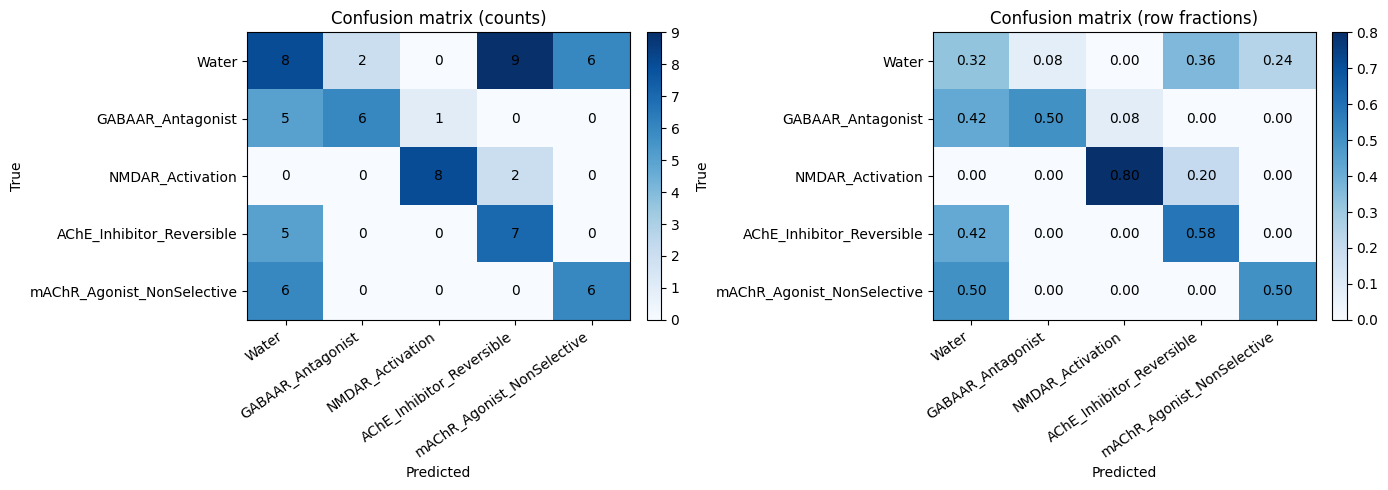


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.333333,0.400,0.363636,25.0
Bemegride,0.000000,0.000,0.000000,6.0
Bicuculline,0.500000,1.000,0.666667,3.0
Gabazine,0.000000,0.000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.375000,1.000,0.545455,3.0
Cis-ACPD,0.000000,0.000,0.000000,3.0
N-methyl-D-aspartate,1.000000,0.500,0.666667,4.0
Donepezil,0.666667,0.500,0.571429,4.0
Galantamine,0.125000,0.500,0.200000,4.0


,value
accuracy,0.323944
macro_precision,0.269231
macro_recall,0.309615
macro_f1,0.247219
weighted_precision,0.311620
weighted_recall,0.323944
weighted_f1,0.282812
n_samples,71.000000
roc_auc_ovr_macro,0.853539
average_precision_macro,0.465413


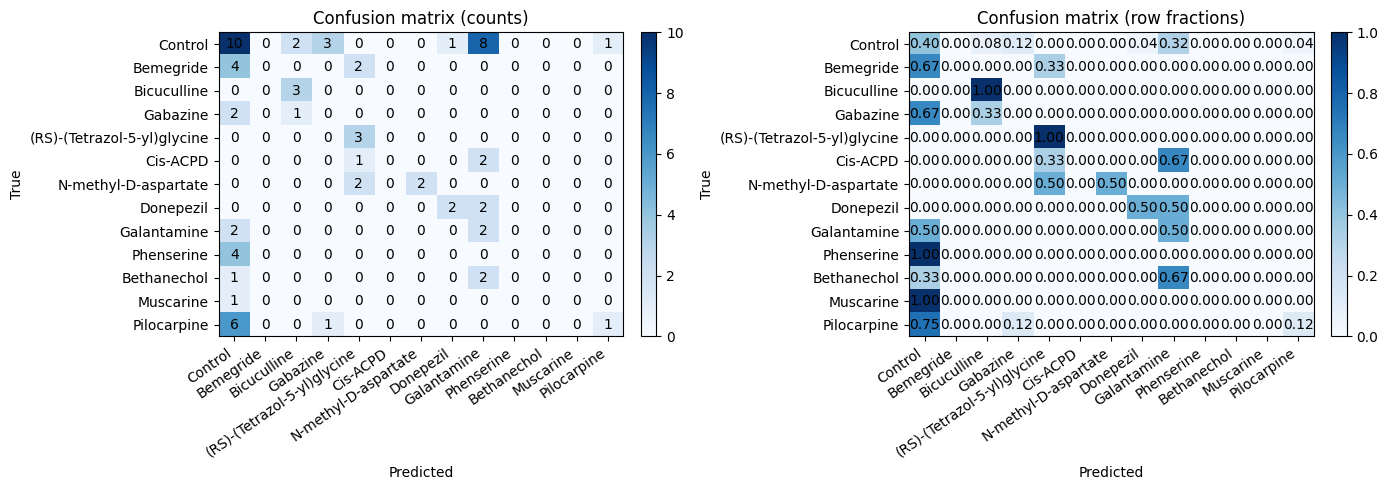


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.392157,0.800000,0.526316,25.0
high,0.642857,0.360000,0.461538,25.0
mid,0.500000,0.142857,0.222222,21.0


,value
accuracy,0.450704
macro_precision,0.511671
macro_recall,0.434286
macro_f1,0.403359
weighted_precision,0.512329
weighted_recall,0.450704
weighted_f1,0.413564
n_samples,71.000000
roc_auc_ovr_macro,0.532588
average_precision_macro,0.432108


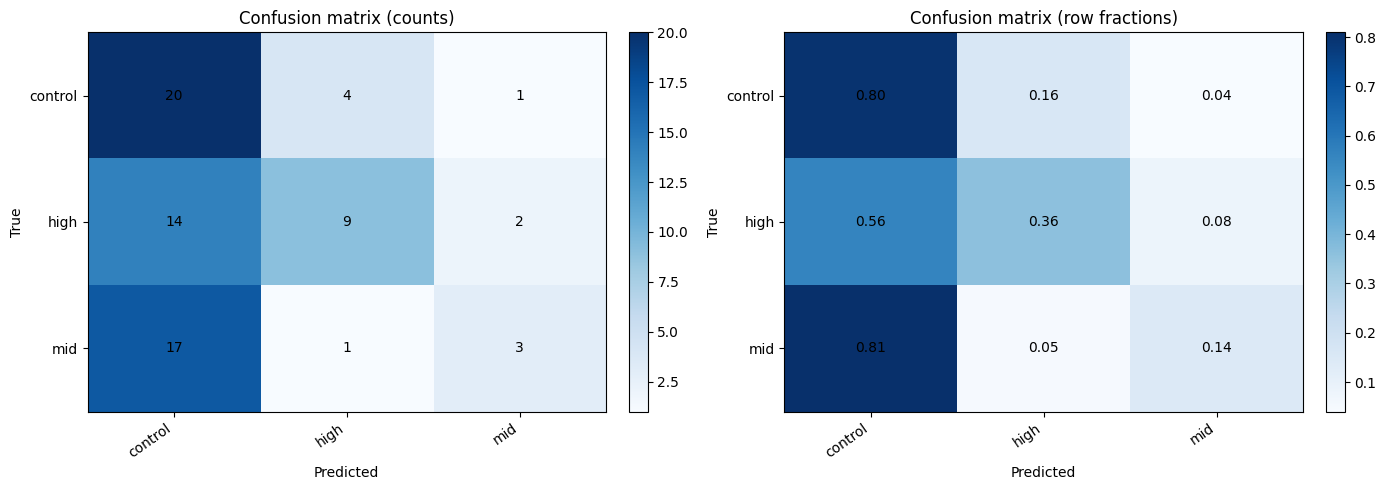

In [ ]:
holdout_evaluation = display_holdout_evaluation(model, experiment)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

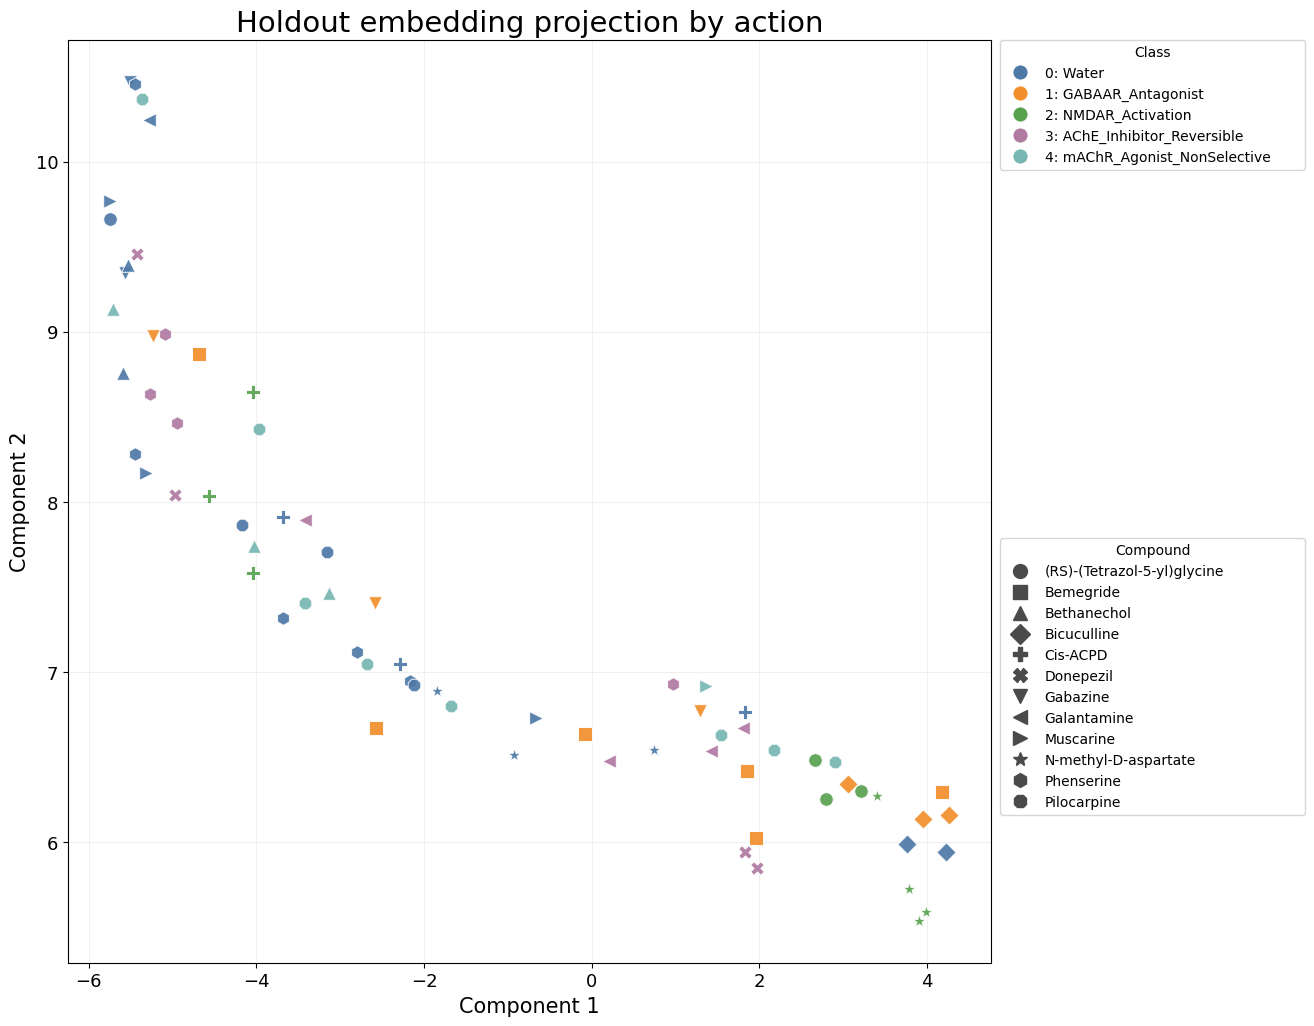

In [ ]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'All labeled data embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

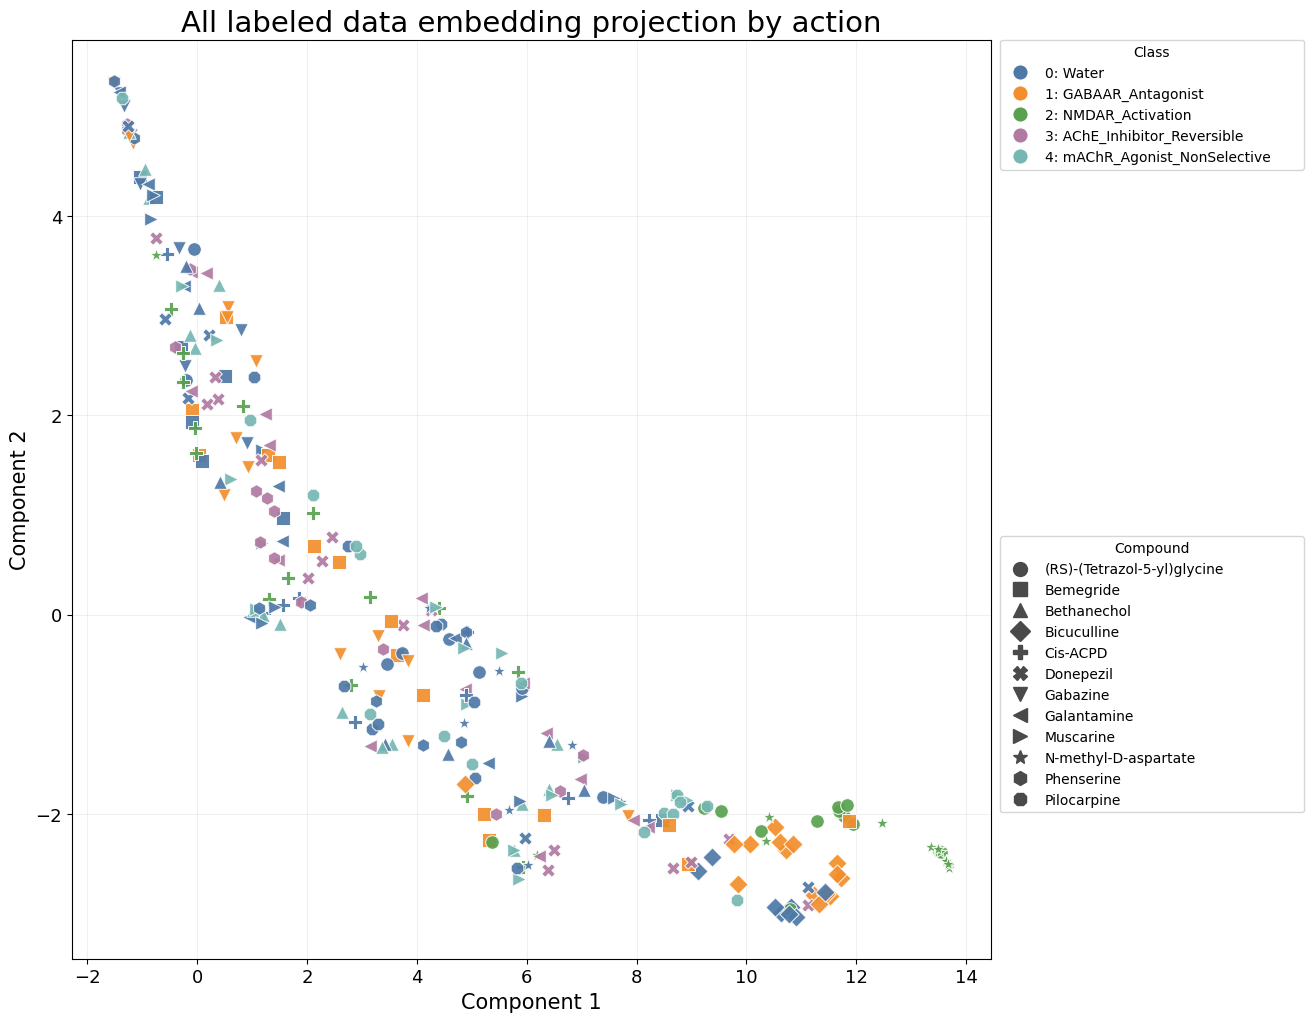

In [ ]:
import torch

all_labeled_tensors = torch.cat(
    [
        experiment.splits.X_train_base,
        experiment.splits.X_val,
        experiment.splits.X_holdout,
    ],
    dim=0,
)
all_action_labels = torch.cat(
    [
        experiment.splits.y_train_base,
        torch.as_tensor(experiment.splits.y_val),
        torch.as_tensor(experiment.splits.y_holdout),
    ]
).numpy()
all_labeled_metadata = pd.concat(
    [
        experiment.splits.metadata_train_base.assign(dataset_split="train"),
        experiment.splits.metadata_val.assign(dataset_split="validation"),
        experiment.splits.metadata_holdout.assign(dataset_split="holdout"),
    ],
    ignore_index=True,
)

all_embedding_projection = build_tensor_embedding_2d(
    model.transform(all_labeled_tensors),
    all_action_labels,
    label_map=experiment.label_maps["action"],
    metadata=all_labeled_metadata,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    all_embedding_projection,
    title="All labeled data embedding projection by action",
    marker_column="compound",
)

In [ ]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "unlabeled_dataset_path": unlabeled_dataset_path,
    "pretraining_config_path": pretraining_config_path,
    "pretrained_encoder_path": pretrained_encoder_path,
    "binary_loss_plot_dir": binary_loss_plot_dir,
    "fine_tune_loss_plot_dir": fine_tune_loss_plot_dir,
    "freeze_backbone": False,
    "hot_start": True,
    "run_binary_hot_start": run_binary_hot_start,
    "binary_pretraining_epochs": binary_pretraining_epochs,
    "binary_learning_rate": binary_learning_rate,
    "binary_weight_decay": binary_weight_decay,
    "binary_class_weighting": binary_class_weighting,
    "binary_pretraining_excluded_holdout_count": None if binary_pretraining_data is None else binary_pretraining_data.excluded_holdout_count,
    "binary_pretraining_label_map": None if binary_pretraining_data is None else binary_pretraining_data.label_map,
    "binary_pretraining_train_count": None if binary_pretraining_data is None else binary_pretraining_data.train_count,
    "binary_pretraining_val_count": None if binary_pretraining_data is None else binary_pretraining_data.val_count,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
    if binary_pretraining_history is not None:
        binary_pretraining_history.to_csv(experiment_output_dir / "binary_pretraining_history.csv", index=False)
    experiment_artifacts
